# AI Programming Foundations Project
## by <i>Andreas Grotz</i>

## Table of Contents
- [Introduction](#intro)
- [Imports](#import)
- [Data Cleaning](#cleaning)
- [Exploratory Analysis](#analysis)
- [Visualization](#visual)
- [Summary](#summary)

<a id='intro'></a>
### Introduction

In this project, we build a pipeline for cleaning and exploring a dataset on Airbnb listings in NYC (https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data). Among others, the dataset contains information on neighbourhood, room type, reviews, and price, and we are going to explore the relations between these types of information. More precisely, we are interested in if and how the price depends on the neighbourhood, room type, and review frequency.

After importing modules and loading the data, we first perform a cleaning of the data. We then run an exploratory data analysis and generate some insightful visualizations, before summarizing our findings.


<a id='import'></a>
### Imports

In this section, we import required Python modules, and we load our dataset to a Pandas dataframe.

In [1]:
#!pip install numpy
#!pip install pandas
#!pip install matplotlib
#!pip install seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


<a id='cleaning'></a>
### Data Cleaning

In this section, we perform data cleaning. First, let's check for duplicates and missing values:

In [4]:
sum(df.duplicated())

0

In [5]:
df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

There is a large amount of missing values in the fields last_review and reviews_per_month. The inspection below shows that this is because these entries do not have any reviews yet, i.e. number_of_reviews is zero for these entries:

In [6]:
df[df.last_review.isna()].number_of_reviews.describe()

count    10052.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: number_of_reviews, dtype: float64

We therefore clean these values by imputation. More precisely, we set reviews_per_month to 0.0 for these entries, which is the correct amount for entries without any reviews yet. We also set the last_review to a dummy date in the distant future (9999-12-31), and convert the column to datetime format.

In [7]:
def clean_review_columns(df):
    """
    A function that cleans missing values in the review columns.
    Cleaning is performed inplace.
    The date in last_review is set to a dummy value 9999-12-31.
    The number in reviews_per_month is set to 0.0.
    
    Args:
        df (dataframe): The Pandas dataframe
        
    Returns:
        None
    """
    df.loc[df.last_review.isna(), 'reviews_per_month']
    df.loc[df.last_review.isna(), 'reviews_per_month'] = 0.0
    df.loc[df.last_review.isna(), 'last_review'] = '9999-12-31'
    df['last_review'] = pd.to_datetime(df['last_review'])

In [8]:
clean_review_columns(df)

Next, we check for outliers in the numerical fields price and reviews_per_month. It turns out that there are far outliers in both fields, which would distort correlation analysis and impede boxplot visualizations. We therefore remove them by cutting off at the 0.5% and 99.5% quantile:

In [9]:
df[['price','reviews_per_month']].describe()

,price,reviews_per_month
count,48895.000000,48895.000000
mean,152.720687,1.090910
std,240.154170,1.597283
min,0.000000,0.000000
25%,69.000000,0.040000
50%,106.000000,0.370000
75%,175.000000,1.580000
max,10000.000000,58.500000


In [10]:
price005 = np.quantile(df.price, q=0.005)
print(f'price 0.5% quantile: {price005}')
price995 = np.quantile(df.price, q=0.995)
print(f'price 99.5% quantile: {price995}')
reviews005 = np.quantile(df.reviews_per_month, q=0.005)
print(f'reviews_per_month 0.5% quantile: {reviews005}')
reviews995 = np.quantile(df.reviews_per_month, q=0.995)
print(f'reviews_per_month 99.5% quantile: {reviews995}')

price 0.5% quantile: 26.0
price 99.5% quantile: 1000.0
reviews_per_month 0.5% quantile: 0.0
reviews_per_month 99.5% quantile: 7.97


In [11]:
def clean_outliers(df, col, qLower, qUpper):
    """
    A function that removes outliers in a given columns, as specified by lower and upper cutoff values.
    Cleaning is performed inplace.
    
    Args:
        df (dataframe): The Pandas dataframe
        col (str): The column name
        qLower float): The lower cutoff value
        qUpper float): The upper cutoff value
        
    Returns:
        None
    """
    indices_to_drop = df[(df[col] < qLower) | (df[col] > qUpper)].index
    df.drop(indices_to_drop, inplace=True)


In [12]:
clean_outliers(df, 'price', price005, price995)

In [13]:
clean_outliers(df, 'reviews_per_month', reviews005, reviews995)

Finally, there are around 20 entries with missing values in the fields name and host_name. These would not be relevant for our further analysis, but we still remove them for the sake of a nice and clean dataset.

In [14]:
def drop_na_values(df):
    """
    A function that removes any rows with NA values.
    Cleaning is performed inplace.
    
    Args:
        df (dataframe): The Pandas dataframe
        
    Returns:
        None
    """
    df.dropna(axis=0, inplace=True)

In [15]:
drop_na_values(df)

In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 48148 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48148 non-null  int64         
 1   name                            48148 non-null  str           
 2   host_id                         48148 non-null  int64         
 3   host_name                       48148 non-null  str           
 4   neighbourhood_group             48148 non-null  str           
 5   neighbourhood                   48148 non-null  str           
 6   latitude                        48148 non-null  float64       
 7   longitude                       48148 non-null  float64       
 8   room_type                       48148 non-null  str           
 9   price                           48148 non-null  int64         
 10  minimum_nights                  48148 non-null  int64         
 11  number_of_reviews 

<a id='analysis'></a>
### Exploratory Analysis

Our goal is to understand the dependence of price on the numerical field reviews_per_month and the categorial fields neighbourhood_group and room_type. We start with the dependence on reviews_per_month by looking at the correlation coefficient:

In [17]:
def get_correlation(df, col1, col2):
    """
    A function that calculates the correlation between two columns in a dataframe.
    Cleaning is performed inplace.
    
    Args:
        df (dataframe): The Pandas dataframe
        col1 (str): Name of the first column
        col2 (str): Name of the second column
        
    Returns:
        float: The correlation between the two columns
    """
    corr_mat = df[[col1, col2]].corr()
    return corr_mat.loc[col1, col2]

In [18]:
get_correlation(df, 'reviews_per_month', 'price')


np.float64(-0.04999983804675285)

The correlation is around -5%, i.e. close to zero. We know that there is a significant number of entries (around 10k) with no reviews at all, so we check if the correlation is different conditional on having at least on review. This is also not the case, indicating that the price is uncorrelated with the review frequency.

In [19]:
get_correlation(df[df.number_of_reviews>0], 'reviews_per_month', 'price')

np.float64(-0.020733768573159686)

Next, we look at the categorial columns neighbourhood_group and room_type by producing grouped descriptive statistics:

In [20]:
def get_grouped_stats(df, stat_col, by_col):
    """
    A function that calculates descriptive statistics for a column in a dataframe, grouped by another column.
    
    Args:
        df (dataframe): The Pandas dataframe
        stat_col (str): Name of the column, for which stats are calculated
        by_col (str): Name of the column, by which data are grouped
        
    Returns:
        dataframe: A dataframe containing the grouped statistics
    """
    return df.groupby(by=by_col)[stat_col].describe()

In [21]:
get_grouped_stats(df, 'price', 'neighbourhood_group')

,count,mean,std,min,25%,50%,75%,max
neighbourhood_group,,,,,,,,
Bronx,1060.0,86.574528,78.251411,26.0,47.0,66.0,99.25,1000.0
Brooklyn,19848.0,118.553255,94.508310,26.0,60.0,91.0,150.00,1000.0
Manhattan,21385.0,179.180734,133.939968,26.0,95.0,150.0,220.00,1000.0
Queens,5493.0,96.206445,75.031928,26.0,50.0,75.0,112.00,1000.0
Staten Island,362.0,100.082873,96.762289,27.0,50.0,75.0,110.00,1000.0


In [22]:
get_grouped_stats(df, 'price', 'room_type')

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,25085.0,194.954993,126.146948,28.0,120.0,160.0,225.0,1000.0
Private room,22022.0,85.157661,68.901868,26.0,50.0,70.0,95.0,1000.0
Shared room,1041.0,72.524496,83.986810,26.0,35.0,50.0,75.0,1000.0


These statistics indicate a clear dependence of the price on both the neighbourhood (Manhatten is most expensive on average and the Bronx is cheapest on average) and the room type (entire apartments are significantly more expensive on average than private or shared rooms).

<a id='visual'></a>
### Visualization

We first look at univariate distributions of the variables under consideration.

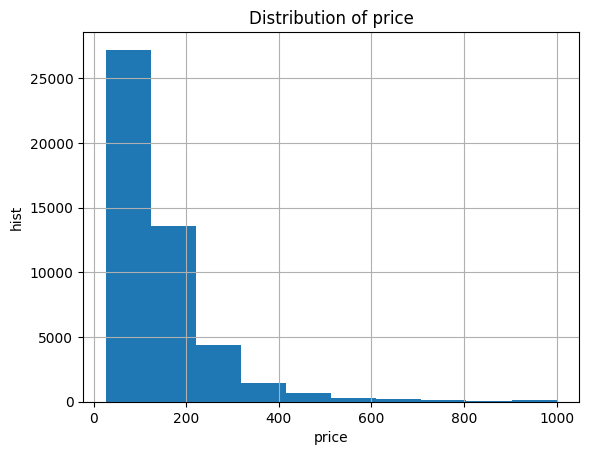

In [23]:
ax = df.price.hist();
plt.xlabel('price')
plt.ylabel('hist')
plt.title('Distribution of price')
plt.show()

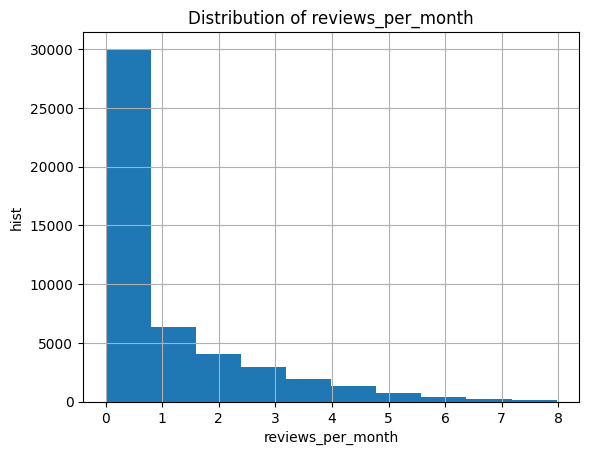

In [24]:
ax = df.reviews_per_month.hist();
plt.xlabel('reviews_per_month')
plt.ylabel('hist')
plt.title('Distribution of reviews_per_month')
plt.show()

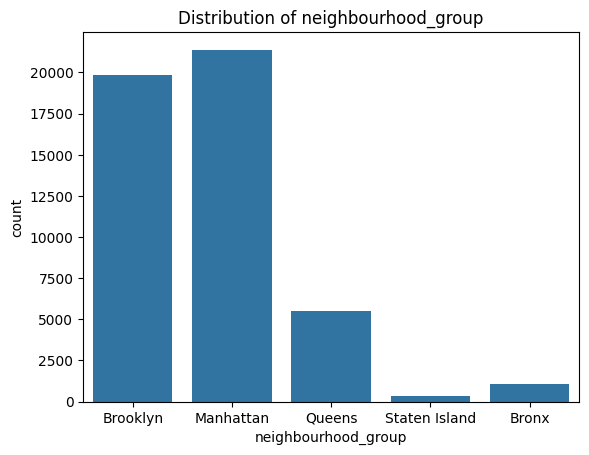

In [25]:
ax = sns.countplot(data=df, x='neighbourhood_group');
plt.xlabel('neighbourhood_group')
plt.ylabel('count')
plt.title('Distribution of neighbourhood_group')
plt.show()

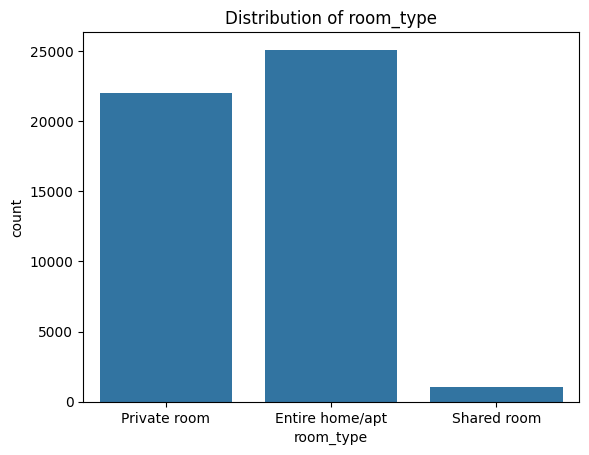

In [26]:
ax = sns.countplot(data=df, x='room_type');
plt.xlabel('room_type')
plt.ylabel('count')
plt.title('Distribution of room_type')
plt.show()

We observe that
- Most entries have prices below USD 200, with outliers out to USD 1,000
- Most entries have less than one review per month, with outliers out to eight reviews per month
- Most entries are based in Manhattan or Brooklyn, some in Queens, and comparably few in Staten Island and the Bronx
- Room type is mostly split between private rooms and entire apartments, with a small fraction of shared rooms

Next we look at bivariate plots, visualizing the dependence of price on the other variables.

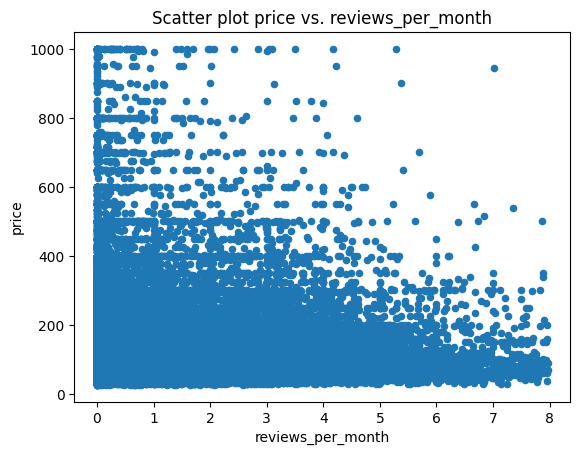

In [27]:
ax = df.plot.scatter(x='reviews_per_month',y='price');
plt.title('Scatter plot price vs. reviews_per_month');
plt.show();

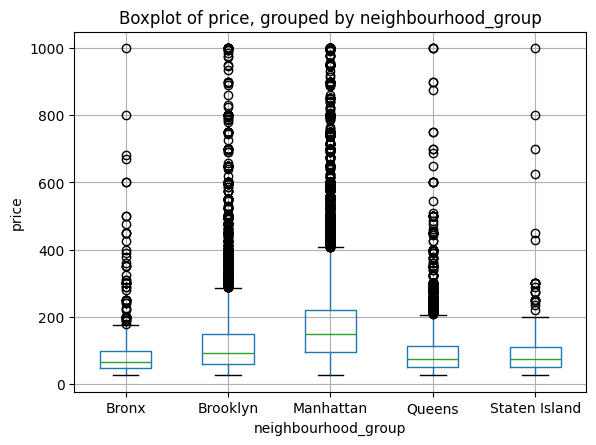

In [28]:
ax = df.boxplot(column='price', by='neighbourhood_group');
plt.xlabel('neighbourhood_group')
plt.ylabel('price')
plt.title('Boxplot of price, grouped by neighbourhood_group')
plt.suptitle('')
plt.show()

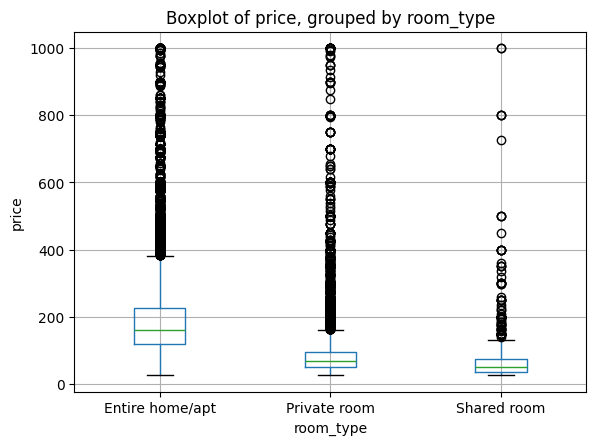

In [29]:
df.boxplot(column='price', by='room_type');
plt.xlabel('room_type')
plt.ylabel('price')
plt.title('Boxplot of price, grouped by room_type')
plt.suptitle('')
plt.show()

We observe that
- the scatter plot shows a slight indication of price linearly decreasing with the reviews_per_month, but we already know better from the close-to-zero correlation coefficient
- the boxplots provide a clear indication that the price depends on neighbourhood_group and room_type

<a id='summary'></a>
### Summary

We have analyzed a dataset on Airbnb listings in NYC with respect to the question whether the price of a listing depends on the factors neighbourhood_group, room_type, and reviews_per_month. 

The dataset is generally of good quality, with some minor cleaning required:
- The reviews_per_month has NA values for entries with no reviews yet, which we updated to the correct value of 0.0 review per month
- There are some outliers in the numerical variables reviews_per_month and price, which we truncated at the 0.5% and 99.5% quantile

Our exploratory analysis and visualizations indicate that
<ol>
<li>there is no correlation between the review frequency and the price</li>
<li>there is a clear dependence of the price (on average and on median) on
    <ol>
    <li>neighbourhood (Manhatten is most expensive on average and the Bronx is cheapest on average)</li>
    <li>and room type (entire apartments are significantly more expensive on average than private or shared rooms)</li>
    </ol>
</li>
</ol>

In [30]:
# Let us finally generate the requirements file for reproducibility.
!pip freeze > requirements.txt